# 1.) Document Q&A with RAG using Chroma

Two big limitations of LLMs are:
1) that they only "know" the information that they were trained on
2) that they have limited input context windows.

A way to address both of these limitations is to use a technique called Retrieval Augmented Generation, or RAG. A RAG system has three stages:

- Indexing
- Retrieval
- Generation

Indexing happens ahead of time, and allows you to quickly look up relevant information at query-time.<br>
When a query comes in, you retrieve relevant documents, combine them with your instructions and the user's query, and have the LLM generate a tailored answer in natural language using the supplied information. <br>
This allows you to provide information that the model hasn't seen before, such as product-specific knowledge or live weather updates.

### 1.1) Setup

In [ ]:
from IPython.display import HTML, Markdown, display

In [ ]:
!pip install google-adk

In [ ]:
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-proto
   

In [ ]:
from google.colab import userdata
api_key = userdata.get('GOOGLE_API_KEY')

In [ ]:
from google import genai
from google.adk.agents import Agent
from google.adk.models.google_llm import Gemini
from google.adk.runners import InMemoryRunner
from google.adk.tools import google_search
from google.genai import types
import os

In [ ]:
# Set API key as environment variable
os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')

retry_config = types.HttpRetryOptions(attempts = 5, # Maximum number of retries
                                      exp_base = 7, # delay multiplier
                                      initial_delay = 1, # Initial delay before first retry (in seconds)
                                      http_status_codes = [429, 500, 502, 503, 504] # On what error codes should the retry engage
                                    )

client = genai.Client(api_key=api_key)

In [ ]:
for model in client.models.list():
  print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-exp-image-generation
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-exp-1206
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-preview-09-2025
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2025
models/gemini-embedding-001
models/aqa
models/imagen-4.0-generate-preview-06-06
models/imagen

### 1.2) RAG and Chroma Experiment

In [ ]:
# Creating a sample document databse. This can be replaced with existing DB or other data sources
DOCUMENT1 = "Operating the Climate Control System  Your Googlecar has a climate control system that allows you to adjust the temperature and airflow in the car. To operate the climate control system, use the buttons and knobs located on the center console.  Temperature: The temperature knob controls the temperature inside the car. Turn the knob clockwise to increase the temperature or counterclockwise to decrease the temperature. Airflow: The airflow knob controls the amount of airflow inside the car. Turn the knob clockwise to increase the airflow or counterclockwise to decrease the airflow. Fan speed: The fan speed knob controls the speed of the fan. Turn the knob clockwise to increase the fan speed or counterclockwise to decrease the fan speed. Mode: The mode button allows you to select the desired mode. The available modes are: Auto: The car will automatically adjust the temperature and airflow to maintain a comfortable level. Cool: The car will blow cool air into the car. Heat: The car will blow warm air into the car. Defrost: The car will blow warm air onto the windshield to defrost it."
DOCUMENT2 = 'Your Googlecar has a large touchscreen display that provides access to a variety of features, including navigation, entertainment, and climate control. To use the touchscreen display, simply touch the desired icon.  For example, you can touch the "Navigation" icon to get directions to your destination or touch the "Music" icon to play your favorite songs.'
DOCUMENT3 = "Shifting Gears Your Googlecar has an automatic transmission. To shift gears, simply move the shift lever to the desired position.  Park: This position is used when you are parked. The wheels are locked and the car cannot move. Reverse: This position is used to back up. Neutral: This position is used when you are stopped at a light or in traffic. The car is not in gear and will not move unless you press the gas pedal. Drive: This position is used to drive forward. Low: This position is used for driving in snow or other slippery conditions."

documents = [DOCUMENT1, DOCUMENT2, DOCUMENT3]

### 1.3) Creating the Embedding database with ChromaDB

In this section we create a custom function to generate embeddings with the Gemini API. We are implementing a `retrieval system`, so the `task_type` for generating the document embeddings is `retrieval_document`.

Later, we will use `retrieval_query` for the query embeddings.

Key words:
- `Documents` are the items that are in the database. They are inserted first, and later retrieved.
- `Queries` are the textual search terms and can be simple keywords or textual descriptions of the desired documents.

In [ ]:
from chromadb import Documents, EmbeddingFunction, Embeddings
from google.api_core import retry

from google.genai import types


# Define a helper to retry when per-minute quota is reached.
is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})


class GeminiEmbeddingFunction(EmbeddingFunction):
    # Specify whether to generate embeddings for documents, or queries
    document_mode = True

    @retry.Retry(predicate=is_retriable)
    def __call__(self, input: Documents) -> Embeddings:
        if self.document_mode:
            embedding_task = "retrieval_document"
        else:
            embedding_task = "retrieval_query"

        response = client.models.embed_content(
            model="models/gemini-embedding-001",
            contents=input,
            config=types.EmbedContentConfig(
                task_type=embedding_task,
            ),
        )
        return [e.values for e in response.embeddings]

Now we create a Chroma `database client` that uses the `GeminiEmbeddingFunction` and populate the database with the documents defined above.

In [ ]:
import chromadb

DB_NAME = "googlecardb"

embed_fn = GeminiEmbeddingFunction()
embed_fn.document_mode = True

chroma_client = chromadb.Client()
db = chroma_client.get_or_create_collection(name=DB_NAME, embedding_function=embed_fn)

db.add(documents=documents, ids=[str(i) for i in range(len(documents))])

/tmp/ipython-input-4060984393.py:5: DeprecationWarning: The class GeminiEmbeddingFunction does not implement __init__. This will be required in a future version.
  embed_fn = GeminiEmbeddingFunction()


In [ ]:
# Confirming that the data was enetered in the database
db.count()

3

In [ ]:
# We can also see the data sample
db.peek(1)

{'ids': ['0'],
 'embeddings': array([[ 0.02383879, -0.0059143 ,  0.01486473, ...,  0.0032396 ,
         -0.023798  , -0.01726905]]),
 'documents': ['Operating the Climate Control System  Your Googlecar has a climate control system that allows you to adjust the temperature and airflow in the car. To operate the climate control system, use the buttons and knobs located on the center console.  Temperature: The temperature knob controls the temperature inside the car. Turn the knob clockwise to increase the temperature or counterclockwise to decrease the temperature. Airflow: The airflow knob controls the amount of airflow inside the car. Turn the knob clockwise to increase the airflow or counterclockwise to decrease the airflow. Fan speed: The fan speed knob controls the speed of the fan. Turn the knob clockwise to increase the fan speed or counterclockwise to decrease the fan speed. Mode: The mode button allows you to select the desired mode. The available modes are: Auto: The car will a

### 1.4) Retrival: Finding the relevant documents

To search the Chroma database, call the `query method`. Note that you also switch to the `retrieval_query` mode of embedding generation.

In [ ]:
# Switch to query mode when generating embeddings.
embed_fn.document_mode = False

# Search the Chroma DB using the specified query.
query = "How do you use the touchscreen to play music?"

result = db.query(query_texts=[query], n_results=1)
[all_passages] = result["documents"]

Markdown(all_passages[0])

Your Googlecar has a large touchscreen display that provides access to a variety of features, including navigation, entertainment, and climate control. To use the touchscreen display, simply touch the desired icon.  For example, you can touch the "Navigation" icon to get directions to your destination or touch the "Music" icon to play your favorite songs.

### 1.5) Augmented Generation: Answering the question

Now that we have found a relevant passage from the set of documents (the retrieval step), we can now assemble a generation prompt to have the Gemini API generate a final answer.

Note that in this example only a single passage was retrieved. In practice, especially when the size of your underlying data is large, we would want to retrieve more than one result and let the Gemini model determine what passages are relevant in answering the question.

For this reason it's OK if some retrieved passages are not directly related to the question - this generation step should ignore them.

In [ ]:
query_oneline = query.replace("\n", " ")

# This prompt is where you can specify any guidance on tone, or what topics the model should stick to, or avoid.
prompt = f"""You are a helpful and informative bot that answers questions using text from the reference passage included below.
Be sure to respond in a complete sentence, being comprehensive, including all relevant background information.
However, you are talking to a non-technical audience, so be sure to break down complicated concepts and
strike a friendly and converstional tone. If the passage is irrelevant to the answer, you may ignore it.

QUESTION: {query_oneline}
"""

# Add the retrieved documents to the prompt.
for passage in all_passages:
    passage_oneline = passage.replace("\n", " ")
    prompt += f"PASSAGE: {passage_oneline}\n"

print(prompt) # Printing the final prompt which will be sent to LLM via api call

You are a helpful and informative bot that answers questions using text from the reference passage included below.
Be sure to respond in a complete sentence, being comprehensive, including all relevant background information.
However, you are talking to a non-technical audience, so be sure to break down complicated concepts and
strike a friendly and converstional tone. If the passage is irrelevant to the answer, you may ignore it.

QUESTION: How do you use the touchscreen to play music?
PASSAGE: Your Googlecar has a large touchscreen display that provides access to a variety of features, including navigation, entertainment, and climate control. To use the touchscreen display, simply touch the desired icon.  For example, you can touch the "Navigation" icon to get directions to your destination or touch the "Music" icon to play your favorite songs.



In [ ]:
# Using the generate method to get an answer to the prompt question passed
answer = client.models.generate_content(
    model="gemini-2.5-flash-lite",
    contents=prompt)

Markdown(answer.text)

Playing your favorite tunes in your Googlecar is super easy with the big touchscreen! You'll want to find and tap the "Music" icon on the display, and then you should be all set to enjoy your music.

# 2) Embeddings and Similarity Scores

### 2.1) Calculating Similarity Scores

This example embeds some variations on the pangram, `The quick brown fox jumps over the lazy dog`, including spelling mistakes and shortenings of the phrase. Another pangram and a somewhat unrelated phrase have been included for comparison.

In this task, you are going to use the embeddings to calculate similarity scores, so the `task_type` for these embeddings is `semantic_similarity`.

In [ ]:
texts = [
    'The quick brown fox jumps over the lazy dog.',
    'The quick rbown fox jumps over the lazy dog.',
    'teh fast fox jumps over the slow woofer.',
    'a quick brown fox jmps over lazy dog.',
    'brown fox jumping over dog',
    'fox > dog',
    # Alternative pangram for comparison:
    'The five boxing wizards jump quickly.',
    # Unrelated text, also for comparison:
    'Lorem ipsum dolor sit amet, consectetur adipiscing elit. Vivamus et hendrerit massa. Sed pulvinar, nisi a lobortis sagittis, neque risus gravida dolor, in porta dui odio vel purus.',
]


response = client.models.embed_content(
    model='models/gemini-embedding-001',
    contents=texts,
    config=types.EmbedContentConfig(task_type='semantic_similarity'))

In [ ]:
# Defining a short helper function that will make it easier to display longer embedding texts in our visualisation.

def truncate(t: str, limit: int = 50) -> str:
  """Truncate labels to fit on the chart."""
  if len(t) > limit:
    return t[:limit-3] + '...'
  else:
    return t

truncated_texts = [truncate(t) for t in texts]

#### Similarity Score of Embedding Vectors

A similarity score of two embedding vectors can be obtained by calculating their **inner product**.

If $\mathbf{u}$ is the first embedding vector, and $\mathbf{v}$ the second, this is:

$$\mathbf{u}^T \mathbf{v}$$

As the API provides embedding vectors that are **normalised to unit length**, this is also the **cosine similarity**.

This score can be computed across all embeddings through the matrix self-multiplication:

$$\text{df} \cdot \text{df}^T$$

In code this is written as:
```python
df @ df.T
```

> **Note:** The range from $0.0$ (completely dissimilar) to $1.0$ (completely similar) is depicted
> in the heatmap from light ($0.0$) to dark ($1.0$).

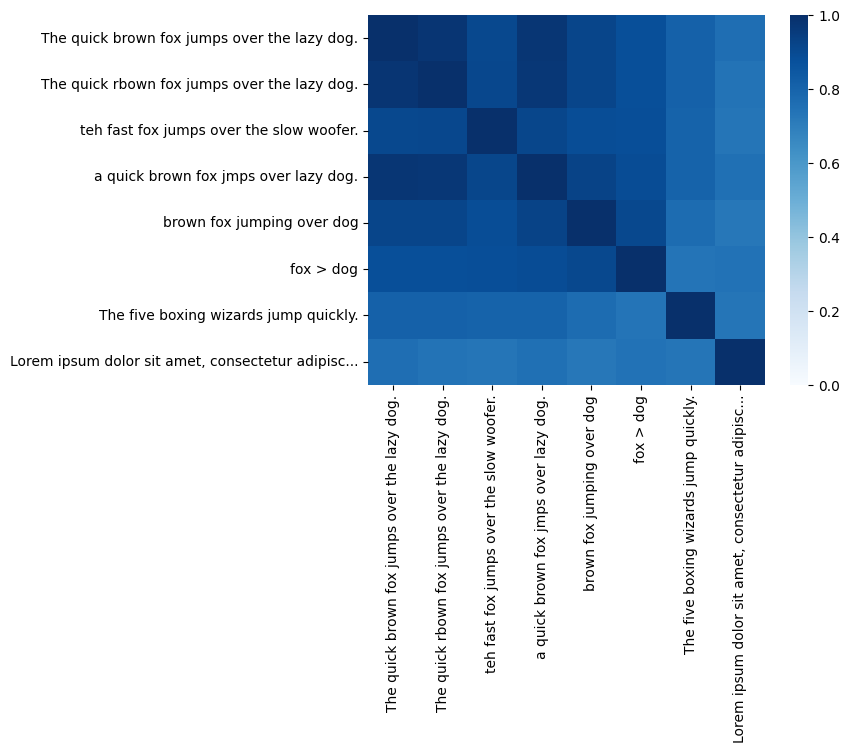

In [ ]:
import pandas as pd
import seaborn as sns


# Set up the embeddings in a dataframe.
df = pd.DataFrame([e.values for e in response.embeddings], index=truncated_texts)
# Perform the similarity calculation
sim = df @ df.T
# Draw!
sns.heatmap(sim, vmin=0, vmax=1, cmap="Blues");

In [ ]:
# the scores for a particular term can be seen directly by looking it up in the dataframe.
sim['The quick brown fox jumps over the lazy dog.'].sort_values(ascending=False)

,The quick brown fox jumps over the lazy dog.
The quick brown fox jumps over the lazy dog.,1.000000
The quick rbown fox jumps over the lazy dog.,0.977811
a quick brown fox jmps over lazy dog.,0.976155
brown fox jumping over dog,0.921726
teh fast fox jumps over the slow woofer.,0.907323
fox > dog,0.882391
The five boxing wizards jump quickly.,0.811250
"Lorem ipsum dolor sit amet, consectetur adipisc...",0.760131


# 3) Classifying Embeddings with Keras

Here we will use the embeddings generated by Gemini API to train a model that can classify newsgroup posts into the categories (the newsgroup itself) from the post contents.

We use the Gemini API's embeddings as input, avoiding the need to train on text input directly, and as a result it is able to perform quite well using relatively few examples compared to training a text model from scratch.

### 3.1) Dataset

The 20 Newsgroups Text Dataset contains 18,000 newsgroups posts on 20 topics divided into training and test sets. The split between the training and test datasets are based on messages posted before and after a specific date.

In [ ]:
from sklearn.datasets import fetch_20newsgroups

newsgroups_train = fetch_20newsgroups(subset="train")
newsgroups_test = fetch_20newsgroups(subset="test")

# View list of class names for dataset
newsgroups_train.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [ ]:
# Sample datapoint
print(newsgroups_train.data[0])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







To remove any sensitive information like names and email addresses, we will take only the subject and body of each message. This is an optional step that transforms the input data into more generic text, rather than email posts, so that it will work in other contexts.

In [ ]:
import email
import re

import pandas as pd

def preprocess_newsgroup_row(data):
    # Extract only the subject and body
    msg = email.message_from_string(data)
    text = f"{msg['Subject']}\n\n{msg.get_payload()}"
    # Strip any remaining email addresses
    text = re.sub(r"[\w\.-]+@[\w\.-]+", "", text)
    # Truncate each entry to 5,000 characters
    text = text[:5000]

    return text

def preprocess_newsgroup_data(newsgroup_dataset):
    # Put data points into dataframe
    df = pd.DataFrame(
        {"Text": newsgroup_dataset.data, "Label": newsgroup_dataset.target}
    )
    # Clean up the text
    df["Text"] = df["Text"].apply(preprocess_newsgroup_row)
    # Match label to target name index
    df["Class Name"] = df["Label"].map(lambda l: newsgroup_dataset.target_names[l])

    return df

In [ ]:
# Apply preprocessing function to training and test datasets
df_train = preprocess_newsgroup_data(newsgroups_train)
df_test = preprocess_newsgroup_data(newsgroups_test)

df_train.head()

,Text,Label,Class Name
0,WHAT car is this!?\n\n I was wondering if anyo...,7,rec.autos
1,SI Clock Poll - Final Call\n\nA fair number of...,4,comp.sys.mac.hardware
2,"PB questions...\n\nwell folks, my mac plus fin...",4,comp.sys.mac.hardware
3,Re: Weitek P9000 ?\n\nRobert J.C. Kyanko () wr...,1,comp.graphics
4,Re: Shuttle Launch Question\n\nFrom article <>...,14,sci.space


We will sample some of the data by taking 100 data points in the training dataset, and dropping a few of the categories to run through this tutorial.

In [ ]:
def sample_data(df, num_samples, classes_to_keep):
    # Sample rows, selecting num_samples of each Label.
    df = (
        df.groupby("Label")[df.columns]
        .apply(lambda x: x.sample(num_samples))
        .reset_index(drop=True)
    )

    df = df[df["Class Name"].str.contains(classes_to_keep)]

    # We have fewer categories now, so re-calibrate the label encoding.
    df["Class Name"] = df["Class Name"].astype("category")
    df["Encoded Label"] = df["Class Name"].cat.codes

    return df

In [ ]:
TRAIN_NUM_SAMPLES = 100
TEST_NUM_SAMPLES = 25
# Class name should contain 'sci' to keep science categories.
CLASSES_TO_KEEP = "sci"

df_train = sample_data(df_train, TRAIN_NUM_SAMPLES, CLASSES_TO_KEEP)
df_test = sample_data(df_test, TEST_NUM_SAMPLES, CLASSES_TO_KEEP)

In [ ]:
df_train.value_counts("Class Name")

,count
Class Name,
sci.crypt,100
sci.electronics,100
sci.med,100
sci.space,100


In [ ]:
df_test.value_counts("Class Name")

,count
Class Name,
sci.crypt,25
sci.electronics,25
sci.med,25
sci.space,25


### 3.2) Embeddings

In [ ]:
from google.api_core import retry
import tqdm
from tqdm.rich import tqdm as tqdmr
import warnings

# Add tqdm to Pandas
tqdmr.pandas()

# Suppress the experimental warning.
warnings.filterwarnings("ignore", category=tqdm.TqdmExperimentalWarning)

# Define a helper to retry when per-minute quota is reached.
is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})

@retry.Retry(predicate=is_retriable, timeout=300.0)
def embed_fn(text: str) -> list[float]:
    # You will be performing classification, so set task_type accordingly.
    response = client.models.embed_content(
        model="models/gemini-embedding-001",
        contents=text,
        config=types.EmbedContentConfig(
            task_type="classification",
        ),
    )

    return response.embeddings[0].values


def create_embeddings(df):
    df["Embeddings"] = df["Text"].progress_apply(embed_fn)
    return df

In [ ]:
df_train = create_embeddings(df_train)
df_test = create_embeddings(df_test)

Output()

Output()

In [ ]:
df_train.head()

,Text,Label,Class Name,Encoded Label,Embeddings
1100,Re: Clipper considered harmful\n\n (Brad Yearw...,11,sci.crypt,0,"[-0.013856576, 0.0059692087, 0.012887776, -0.0..."
1101,Re: Off the shelf cheap DES keyseach machine (...,11,sci.crypt,0,"[-0.01829335, -0.0062044486, 0.0010498615, -0...."
1102,PGP 2.0 vs 2.2\n\n\nI've seen PGP 2.2 mentione...,11,sci.crypt,0,"[-0.01735995, -0.013954937, 0.00048445334, -0...."
1103,"Re: Once tapped, your code is no good any more...",11,sci.crypt,0,"[0.0110664265, 0.003856177, 0.020519612, -0.04..."
1104,"Re: Once tapped, your code is no good any more...",11,sci.crypt,0,"[-0.009174054, 0.0028515288, 0.011050062, -0.0..."


### 3.3) Building a Classification

We will define a simple model that accepts the raw embedding data as input, has one hidden layer, and an output layer specifying the class probabilities. The prediction will correspond to the probability of a piece of text being a particular class of news.

In [ ]:
import keras
from keras import layers


def build_classification_model(input_size: int, num_classes: int) -> keras.Model:
    return keras.Sequential(
        [
            layers.Input([input_size], name="embedding_inputs"),
            layers.Dense(input_size, activation="relu", name="hidden"),
            layers.Dense(num_classes, activation="softmax", name="output_probs"),
        ]
    )

In [ ]:
# Derive the embedding size from observing the data. The embedding size can also be specified
# with the `output_dimensionality` parameter to `embed_content` if you need to reduce it.
embedding_size = len(df_train["Embeddings"].iloc[0])

classifier = build_classification_model(
    embedding_size, len(df_train["Class Name"].unique())
)
classifier.summary()

classifier.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"],
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 3072)           │     9,440,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_probs (Dense)            │ (None, 4)              │        12,292 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,452,548 (36.06 MB)

 Trainable params: 9,452,548 (36.06 MB)

 Non-trainable params: 0 (0.00 B)

### 3.4) Training the Model

In [ ]:
import numpy as np


NUM_EPOCHS = 20
BATCH_SIZE = 32

# Split the x and y components of the train and validation subsets.
y_train = df_train["Encoded Label"]
x_train = np.stack(df_train["Embeddings"])
y_val = df_test["Encoded Label"]
x_val = np.stack(df_test["Embeddings"])

# Specify that it's OK to stop early if accuracy stabilises.
early_stop = keras.callbacks.EarlyStopping(monitor="accuracy", patience=3)

# Train the model for the desired number of epochs.
history = classifier.fit(
    x=x_train,
    y=y_train,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    batch_size=BATCH_SIZE,
    epochs=NUM_EPOCHS,
)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6457 - loss: 1.0851 - val_accuracy: 0.9300 - val_loss: 0.3979
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9711 - loss: 0.2140 - val_accuracy: 0.9400 - val_loss: 0.2047
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9916 - loss: 0.0770 - val_accuracy: 0.9500 - val_loss: 0.2015
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 1.0000 - loss: 0.0337 - val_accuracy: 0.9500 - val_loss: 0.1748
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 1.0000 - loss: 0.0176 - val_accuracy: 0.9600 - val_loss: 0.1687
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 1.0000 - loss: 0.0108 - val_accuracy: 0.9500 - val_loss: 0.1716
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 1.0000 - loss: 0.0071 - val_accuracy: 0.9500 - val_loss: 0.1674


### 3.5) Model Evaluation and Custom Prediction

In [ ]:
classifier.evaluate(x=x_val, y=y_val, return_dict=True)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9404 - loss: 0.1665


{'accuracy': 0.949999988079071, 'loss': 0.16738121211528778}

In [ ]:
def make_prediction(text: str) -> list[float]:
  """Infer categories from the provided text."""
  # model takes embeddings as input
  embedded = embed_fn(new_text)

  # input must be batched, so here they are wrapped as a list to provide a batch of 1.
  inp = np.array([embedded])

  # And un-batched here.
  [result] = classifier.predict(inp)
  return result

In [ ]:
# This example avoids any space-specific terminology to see if the model avoids biases towards specific jargon.
new_text = """
First-timer looking to get out of here.

Hi, I'm writing about my interest in travelling to the outer limits!

What kind of craft can I buy? What is easiest to access from this 3rd rock?

Let me know how to do that please.
"""

result = make_prediction(new_text)

for idx, category in enumerate(df_test["Class Name"].cat.categories):
    print(f"{category}: {result[idx] * 100:0.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
sci.crypt: 0.01%
sci.electronics: 0.10%
sci.med: 0.12%
sci.space: 99.77%


# Resources

1. https://www.kaggle.com/whitepaper-embeddings-and-vector-stores?_gl=1*16k55ez*_ga*NTEzMTcxNzY5LjE3NjE1MTAyOTY.*_ga_T7QHS60L4Q*czE3NzA4NzU3MjUkbzI0JGcxJHQxNzcwODc1NzM2JGo0OSRsMCRoMA..

2. https://www.kaggle.com/code/markishere/day-2-document-q-a-with-rag

3. https://www.kaggle.com/code/markishere/day-2-embeddings-and-similarity-scores

4. https://www.kaggle.com/code/markishere/day-2-classifying-embeddings-with-keras